Explanatory Data Analysis



This section explores the cleaned Mobile Usage Behavioral Analysis dataset (1000 users).
Our aim is to understand usage patterns, identify high-risk behavior clusters, and analyze demographics (age, gender, city) that show higher chances of burnout.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import pandas as pd
import os
import re
from sklearn.preprocessing import StandardScaler


Load Dataset and Inspect

In [4]:
df = pd.read_csv("/Users/meenakshsinghania04/Desktop/DM--Smartphone-Usage-and-app-trends/data/processed/mobile_usage_behavioral_analysis_cleaned.csv")
print("Shape:", df.shape)
df.head()


Shape: (1000, 10)


,User_ID,Age,Gender,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours,Location
0,1.0,56.0,Male,2.61,7.15,24.0,4.43,0.55,2.40,Los Angeles
1,2.0,46.0,Male,2.13,13.79,18.0,4.67,4.42,2.43,Chicago
2,3.0,32.0,Female,7.28,4.50,11.0,4.58,1.71,2.83,Houston
3,4.0,25.0,Female,1.20,6.29,21.0,3.18,3.42,4.58,Phoenix
4,5.0,38.0,Male,6.31,12.59,14.0,3.15,0.13,4.00,New York


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       1000 non-null   float64
 1   Age                           1000 non-null   float64
 2   Gender                        1000 non-null   object 
 3   Total_App_Usage_Hours         1000 non-null   float64
 4   Daily_Screen_Time_Hours       1000 non-null   float64
 5   Number_of_Apps_Used           1000 non-null   float64
 6   Social_Media_Usage_Hours      1000 non-null   float64
 7   Productivity_App_Usage_Hours  1000 non-null   float64
 8   Gaming_App_Usage_Hours        1000 non-null   float64
 9   Location                      1000 non-null   object 
dtypes: float64(8), object(2)
memory usage: 78.3+ KB


In [6]:
df.describe()


,User_ID,Age,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,38.745000,6.405670,7.696310,16.64700,2.456330,2.495270,2.475410
std,288.819436,12.186734,3.134855,3.714187,7.61961,1.439525,1.443392,1.450362
min,1.000000,18.000000,1.000000,1.010000,3.00000,0.000000,0.000000,0.010000
25%,250.750000,28.000000,3.590000,4.530000,10.00000,1.200000,1.282500,1.220000
50%,500.500000,40.000000,6.455000,7.880000,17.00000,2.445000,2.435000,2.455000
75%,750.250000,50.000000,9.122500,10.910000,23.00000,3.672500,3.710000,3.782500
max,1000.000000,59.000000,11.970000,14.000000,29.00000,4.990000,5.000000,5.000000


In [7]:
df.isna().sum()


User_ID                         0
Age                             0
Gender                          0
Total_App_Usage_Hours           0
Daily_Screen_Time_Hours         0
Number_of_Apps_Used             0
Social_Media_Usage_Hours        0
Productivity_App_Usage_Hours    0
Gaming_App_Usage_Hours          0
Location                        0
dtype: int64

Handle Categorical Variables (Gender, Location)
Gender → Category Type

Location → Category Type

In [8]:
df['Gender'] = df['Gender'].astype('category')
df['Location'] = df['Location'].astype('category')


Outlier Detection & Handling (IQR Method)
Many variables like screen time or social media usage show extreme values.

To avoid misleading patterns, outliers are capped using:

Q1 − 1.5 * IQR

Q3 + 1.5 * IQR

This makes the dataset more balanced and reliable for EDA

In [9]:
num_cols = [
    "Age", "Total_App_Usage_Hours", "Daily_Screen_Time_Hours",
    "Number_of_Apps_Used", "Social_Media_Usage_Hours",
    "Productivity_App_Usage_Hours", "Gaming_App_Usage_Hours"
]

def cap_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

for c in num_cols:
    cap_outliers(c)


1. Distribution of Daily Screen Time
This visualization helps identify high daily usage, a primary indicator of overuse or burnout.


Whether usage clusters around healthy/average levels

How many users cross the “high usage” threshold

Early signs of compulsive usage patterns

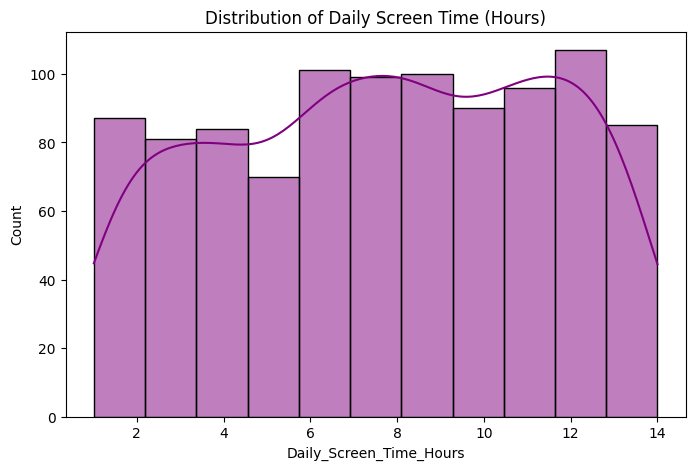

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["Daily_Screen_Time_Hours"], kde=True, color='purple')
plt.title("Distribution of Daily Screen Time (Hours)")
plt.show()


2. Screen Time vs Social Media Usage

Social media usage is directly linked to:

Attention overload

Compulsive checking behavior

Burnout risk

This scatterplot helps identify groups with unusually high social media duration → potential early burnout signals.

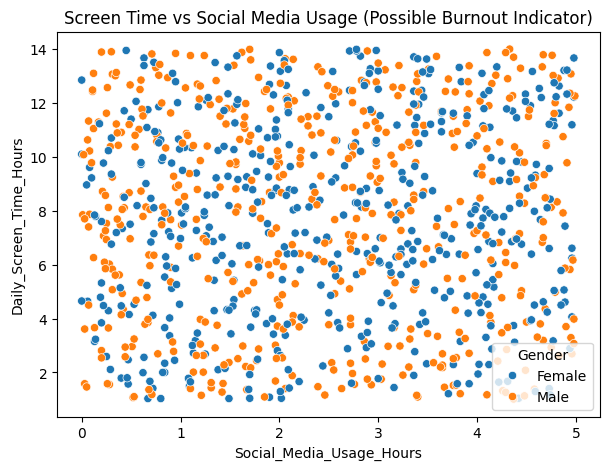

In [11]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df["Social_Media_Usage_Hours"],
    y=df["Daily_Screen_Time_Hours"],
    hue=df["Gender"]
)
plt.title("Screen Time vs Social Media Usage (Possible Burnout Indicator)")
plt.show()


3. Category-Wise App Usage Heatmap

A correlation heatmap is generated for:

Social media hours

Productivity hours

Gaming hours

Screen time

Number of apps used

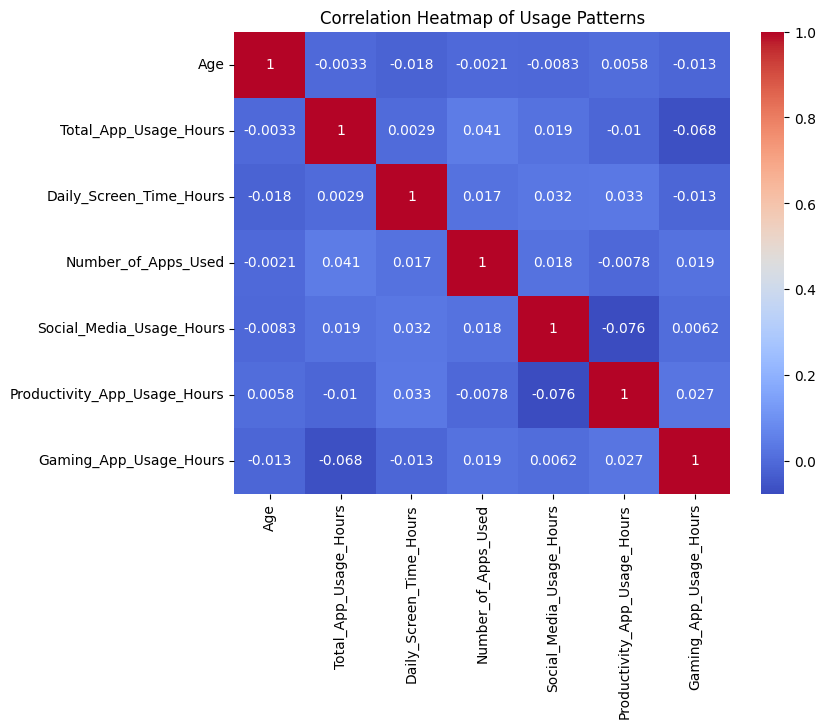

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Usage Patterns")
plt.show()


4. Screen Time by Gender
A boxplot compares screen time across demographic groups.

This helps identify:

Gender-based differences in digital usage

Higher-risk groups

Behavioral tendencies

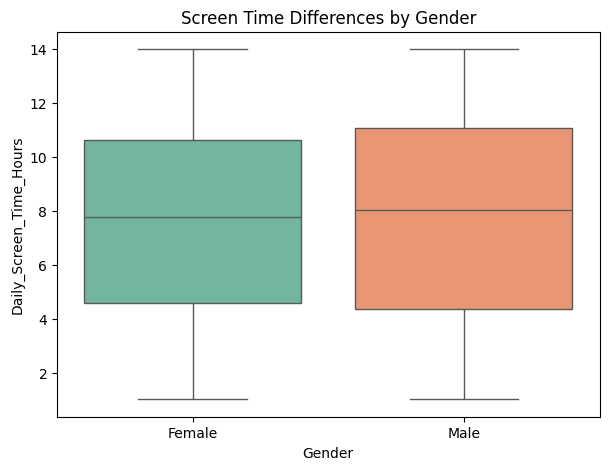

In [13]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Gender", y="Daily_Screen_Time_Hours", hue="Gender", palette="Set2", legend=False)
plt.title("Screen Time Differences by Gender")
plt.show()

5. Location-wise Screen Time

City-level patterns help detect:

Urban vs suburban digital lifestyle differences

Higher burnout in fast-paced cities

Environmental impact on smartphone engagement

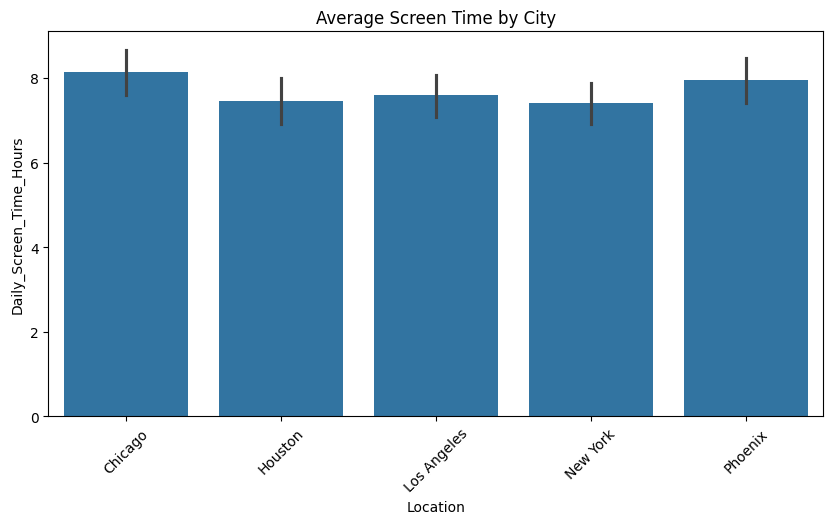

In [14]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="Location", y="Daily_Screen_Time_Hours")
plt.xticks(rotation=45)
plt.title("Average Screen Time by City")
plt.show()


6. Apps Used vs Screen Time

If installing/using more apps increases daily screen time

Signs of multitasking overload

App consumption diversity related to burnout

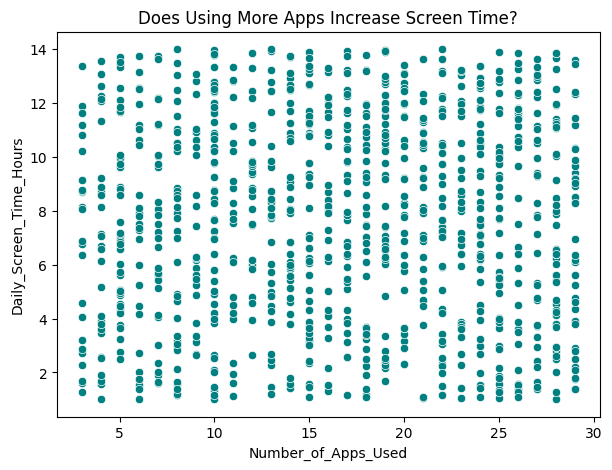

In [15]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df["Number_of_Apps_Used"],
    y=df["Daily_Screen_Time_Hours"],
    color="teal"
)
plt.title("Does Using More Apps Increase Screen Time?")
plt.show()


7. Gaming vs Daily Screen Time

  Gaming is associated with:

Late night usage

Dopamine-driven repetition

Addiction-like tendencies

This plot highlights whether heavy gaming users fall into burnout zones.

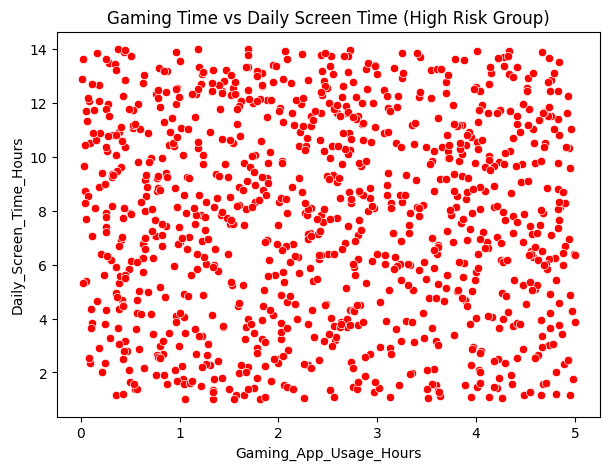

In [16]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df["Gaming_App_Usage_Hours"],
    y=df["Daily_Screen_Time_Hours"],
    color="red"
)
plt.title("Gaming Time vs Daily Screen Time (High Risk Group)")
plt.show()


8. Screen Time & App Usage by Age Group

Age groups (10–20, 20–30, … 60–70) help identify:

Young adults typically show higher risk

Middle-aged users balance productivity vs entertainment

Seniors show steady or low usage

This identifies which age segments require more digital-wellness intervention.

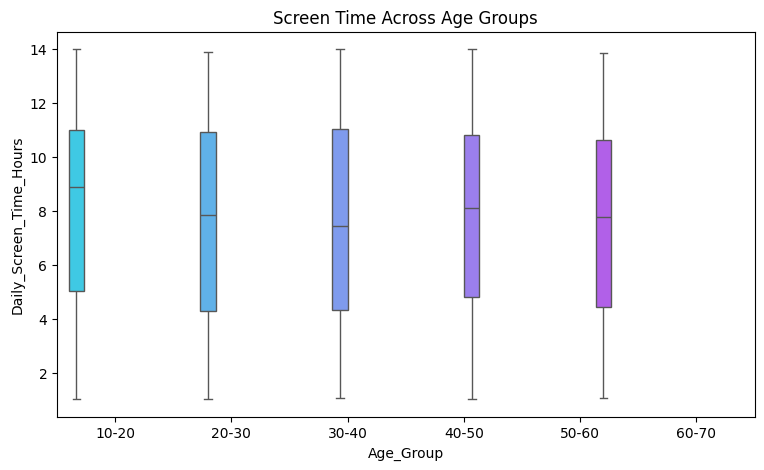

In [17]:
df["Age_Group"] = pd.cut(df["Age"], bins=[10,20,30,40,50,60,70],
labels=["10-20","20-30","30-40","40-50","50-60","60-70"])

plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="Age_Group", y="Daily_Screen_Time_Hours", hue="Age_Group", palette="cool", legend=False)
plt.title("Screen Time Across Age Groups")
plt.show()